In [2]:
from google.colab import files
files.upload()

Saving glp1_test.csv to glp1_test.csv
Saving glp1_train.csv to glp1_train.csv


{'glp1_test.csv': b'Units Reimbursed,Number of Prescriptions,State_AK,State_AL,State_AR,State_AZ,State_CA,State_CO,State_CT,State_DC,State_DE,State_FL,State_GA,State_HI,State_IA,State_ID,State_IL,State_IN,State_KS,State_KY,State_LA,State_MA,State_MD,Product Name_BYDUREON,Product Name_BYETTA,Product Name_MOUNJARO,Product Name_OZEMPIC,Product Name_RYBELSUS,Product Name_SAXENDA,Product Name_TRULICITY,Product Name_VICTOZA,Product Name_WEGOVY,Product Name_ZEPBOUND,Utilization Type_FFSU,Utilization Type_MCOU,Quarter_1,Quarter_2,Coverage Bucket\n-0.17242188614540016,-0.1905223290026127,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1\n-0.1876412882054814,-0.23090506092019786,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1\n-0.21887729910021958,-0.23965721194416117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

Train: (1164, 37)  |  Test: (291, 37)
Target distribution (train):
Coverage Bucket
1    1042
0     122

Class weights: {np.int64(0): np.float64(4.770491803278689), np.int64(1): np.float64(0.5585412667946257)}

✅ Model trained.

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Bucket 0       0.72      0.93      0.81        30
    Bucket 1       0.99      0.96      0.97       261

    accuracy                           0.96       291
   macro avg       0.86      0.95      0.89       291
weighted avg       0.96      0.96      0.96       291

ROC-AUC Score: 0.9906



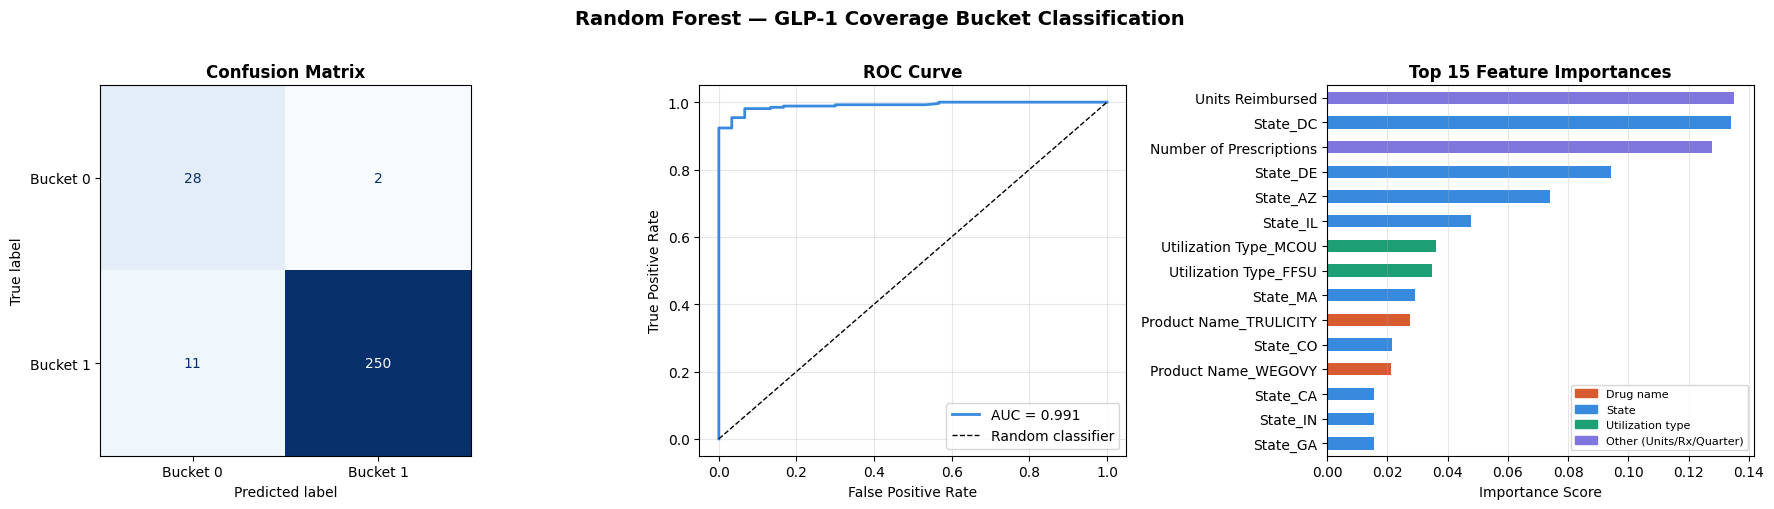

✅ Plots saved to rf_results.png

SUMMARY TABLE
              Metric  Score
            Accuracy 0.9553
Precision (Bucket 0) 0.7179
Precision (Bucket 1) 0.9921
   Recall (Bucket 0) 0.9333
   Recall (Bucket 1) 0.9579
       F1 (Bucket 0) 0.8116
       F1 (Bucket 1) 0.9747
             ROC-AUC 0.9906

TOP 10 FEATURE IMPORTANCES
  Units Reimbursed                    0.1350
  State_DC                            0.1341
  Number of Prescriptions             0.1279
  State_DE                            0.0941
  State_AZ                            0.0741
  State_IL                            0.0477
  Utilization Type_MCOU               0.0361
  Utilization Type_FFSU               0.0349
  State_MA                            0.0292
  Product Name_TRULICITY              0.0274
Macro F1 Score: 0.8931


In [4]:

# Random Forest Model — GLP-1 Drug Coverage Bucket
# Predicts whether a drug record falls in Coverage Bucket 0 or 1


#IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
)
from sklearn.utils.class_weight import compute_class_weight

# ── 1. LOAD DATA
train = pd.read_csv("glp1_train.csv")
test  = pd.read_csv("glp1_test.csv")

TARGET = "Coverage Bucket"
FEATURES = [c for c in train.columns if c != TARGET]

X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Target distribution (train):\n{y_train.value_counts().to_string()}\n")

# ── 2. HANDLE CLASS IMBALANCE (89% class 1, 10% class 0) ───
# Use class_weight='balanced' so the minority class (0) is not ignored
classes = np.array([0, 1])
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print(f"Class weights: {class_weight_dict}\n")

# ── 3. TRAIN RANDOM FOREST
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train, y_train)
print("✅ Model trained.\n")

# ── 4. PREDICTIONS
y_pred      = rf.predict(X_test)
y_pred_prob = rf.predict_proba(X_test)[:, 1]

# ── 5. EVALUATION METRICS
print("=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=["Bucket 0", "Bucket 1"]))

auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC-AUC Score: {auc:.4f}\n")

# ── 6. PLOTS
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Random Forest — GLP-1 Coverage Bucket Classification", fontsize=14, fontweight="bold", y=1.01)

# --- Plot 1: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Bucket 0", "Bucket 1"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix", fontweight="bold")

# --- Plot 2: ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color="#378ADD", lw=2, label=f"AUC = {auc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontweight="bold")
axes[1].legend(loc="lower right")
axes[1].set_facecolor("white")
axes[1].grid(True, alpha=0.3)

# --- Plot 3: Top 15 Feature Importances ---
feat_imp = pd.Series(rf.feature_importances_, index=FEATURES).nlargest(15).sort_values()
colors = ["#D85A30" if "Product" in i else "#378ADD" if "State" in i
          else "#1D9E75" if "Utilization" in i else "#7F77DD"
          for i in feat_imp.index]
feat_imp.plot(kind="barh", ax=axes[2], color=colors)
axes[2].set_title("Top 15 Feature Importances", fontweight="bold")
axes[2].set_xlabel("Importance Score")
axes[2].set_facecolor("white")
axes[2].grid(True, axis="x", alpha=0.3)

# Legend for feature importance colors
legend_patches = [
    mpatches.Patch(color="#D85A30", label="Drug name"),
    mpatches.Patch(color="#378ADD", label="State"),
    mpatches.Patch(color="#1D9E75", label="Utilization type"),
    mpatches.Patch(color="#7F77DD", label="Other (Units/Rx/Quarter)"),
]
axes[2].legend(handles=legend_patches, fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("rf_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plots saved to rf_results.png")

# ── 7. SUMMARY TABLE ────────────────────────────────────────
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (Bucket 0)", "Precision (Bucket 1)",
               "Recall (Bucket 0)", "Recall (Bucket 1)",
               "F1 (Bucket 0)", "F1 (Bucket 1)", "ROC-AUC"],
    "Score": [
        round(accuracy_score(y_test, y_pred), 4),
        round(precision_score(y_test, y_pred, pos_label=0), 4),
        round(precision_score(y_test, y_pred, pos_label=1), 4),
        round(recall_score(y_test, y_pred, pos_label=0), 4),
        round(recall_score(y_test, y_pred, pos_label=1), 4),
        round(f1_score(y_test, y_pred, pos_label=0), 4),
        round(f1_score(y_test, y_pred, pos_label=1), 4),
        round(auc, 4),
    ]
})

print("\n" + "=" * 35)
print("SUMMARY TABLE")
print("=" * 35)
print(summary.to_string(index=False))

# ── 8. TOP FEATURE IMPORTANCES (text) ───────────────────────
print("\n" + "=" * 35)
print("TOP 10 FEATURE IMPORTANCES")
print("=" * 35)
top10_feat = pd.Series(rf.feature_importances_, index=FEATURES).nlargest(10)
for feat, score in top10_feat.items():
    print(f"  {feat:<35} {score:.4f}")

    from sklearn.metrics import f1_score
macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f"Macro F1 Score: {macro_f1:.4f}")